# Домашнее задание: Занятие 36

**Тема: Практическое применение современных архитектур -- CLIP, Stable Diffusion, SAM**

## Часть 1: Теория

Отвечайте своими словами, не копируйте.

### Вопрос 1

*(Слайды 6-8)*

Объясните, как CLIP связывает текст и картинки. Что такое Contrastive Learning в контексте CLIP?
Опишите процесс обучения: что происходит с матрицей сходства N x N, что модель максимизирует, а что минимизирует.
Почему после обучения можно классифицировать картинки текстом без дополнительного обучения (zero-shot)?

**Ваш ответ:**
CLIP использует два энкодера, один для текста и один для картинок. Они переводят данные в единое пространство векторов. Contrastive Learning - это метод сопоставления пар. В матрице сходства NxN на диагонали стоят правильные пары, текст соответствует картинке, а в остальных ячейках неправильные. Модель максимизирует значения на диагонали и минимизирует все остальные. После обучения CLIP понимает концепции, поэтому в режиме zero-shot он просто сравнивает вектор новой картинки с векторами названий классов и выбирает самый похожий вариант


### Вопрос 2

*(Слайды 10, 5)*

Сравните два подхода к классификации изображений: fine-tuned ResNet и CLIP zero-shot.
В каких ситуациях ResNet будет лучше? Когда лучше использовать CLIP?
Приведите конкретный пример задачи, где CLIP незаменим (подумайте про новые классы, которых не было при обучении).

**Ваш ответ:**
ResNet лучше там, где набор классов фиксирован и важна максимальная точность на конкретных данных, например, брак на заводе. CLIP лучше для гибких задач и поиска по описанию. CLIP незаменим, когда нужно найти объект, которого не было в обучающей выборке, например, "розовый слон в скафандре". ResNet не поймет этот класс, а CLIP сопоставит текстовое описание с визуальными признаками


### Вопрос 3

*(Слайды 12-13)*

Объясните, как работает Stable Diffusion. Опишите три компонента (CLIP Text Encoder, U-Net, VAE) и роль каждого.
Что такое latent space и почему работа в latent space (64x64) вместо pixel space (512x512) ускоряет генерацию?
Как связан U-Net в Stable Diffusion с ResNet, который мы изучали на прошлом занятии?

**Ваш ответ:**
VAE сжимает картинку в маленькое латентное пространство и разжимает обратно. CLIP Text Encoder превращает текст в подсказки для модели. U-Net постепенно убирает шум из латентного представления, ориентируясь на текст. Работа в 64x64 вместо 512x512 ускоряет процесс, так как данных в 64 раза меньше. U-Net внутри состоит из блоков, похожих на ResNet, что помогает сохранять детали при передаче сигналов


### Вопрос 4

*(Слайды 17-18)*

Сравните Vision Transformer (ViT), который используется в SAM, с обычной CNN (ResNet).
Как CNN видит картинку (рецептивное поле, свертки 3x3)? Как ViT видит картинку (патчи, self-attention)?
Почему для задачи сегментации глобальный контекст ViT важнее, чем локальные свертки CNN?

**Ваш ответ:**
CNN смотрит на картинку через маленькое окошко 3x3, собирая информацию локально и постепенно. ViT разбивает картинку на квадраты и через self-attention сразу сравнивает каждый квадрат со всеми остальными. Для сегментации в SAM глобальный контекст ViT важен, потому что модель должна понимать границы целого объекта, а не просто видеть отдельные текстуры или края


### Вопрос 5

*(Слайды 5, 21)*

На занятиях 35-36 мы изучили: CNN, ResNet (skip connections), RNN, LSTM (гейты), Transformer (attention), CLIP, SD, SAM.
Объясните, в чем ключевое отличие Transformer от CNN и RNN. Что такое attention и почему он решает проблемы обоих подходов?
Приведите пример задачи из таблицы на слайде 21, где вы бы использовали каждый из подходов.

**Ваш ответ:**
CNN ограничена локальными зонами, а RNN медленная и плохо помнит начало длинных данных. Transformer через attention может связать любые части данных между собой, независимо от расстояния. Это решает проблему памяти и ограниченного обзора. Например:
- CNN/ResNet: классификация рентгеновских снимков
- RNN/LSTM: прогноз погоды на основе простых временных рядов
- Transformer/CLIP: поиск нужного кадра в видеоархиве по текстовому описанию


---

## Часть 2: Код

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import time

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


### Задание 1: CLIP -- свои классы и prompt engineering

*(Слайды 6-10)*

На практике мы использовали стандартные классы CIFAR-10. Теперь попробуйте свои.

Что надо сделать:

а) Загрузите CLIP ViT-B/32 и скачайте 5 картинок из интернета на разные темы (еда, животные, техника -- что угодно).
Используйте `urllib.request.urlretrieve(url, filename)` для скачивания.

б) Придумайте 8-10 текстовых описаний классов и классифицируйте каждую картинку.
Выведите вероятности для каждой картинки в виде таблицы или графика.

в) Попробуйте минимум 3 разных шаблона промптов для одних и тех же классов:
- просто название класса (`'cat'`)
- `'a photo of a cat'`
- `'a close-up photo of a cat, high quality'`

Покажите, как меняются вероятности. Какой шаблон работает лучше?

г) Попробуйте «обмануть» CLIP -- найдите случай, когда модель ошибается. Объясните почему.

In [2]:
!pip install openai-clip -q
import clip
import torch
from PIL import Image
import urllib.request
import matplotlib.pyplot as plt
import os

# а) Загрузка CLIP и скачивание картинок
model, preprocess = clip.load("ViT-B/32", device=device)

urls = [
    "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Red_Apple.jpg/1200px-Red_Apple.jpg",
    "https://img.freepik.com/free-photo/beautiful-view-sea-with-cloudy-sky-reflected-it_181624-48086.jpg",
    "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a1/Statue_of_Liberty_7.jpg/330px-Statue_of_Liberty_7.jpg"
]

filenames = []

opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

for i, url in enumerate(urls):
    name = f"img_{i}.jpg"
    try:
        urllib.request.urlretrieve(url, name)
        if os.path.exists(name) and os.path.getsize(name) > 0:
            filenames.append(name)
            print(f"Успешно скачано: {name}")
    except Exception as e:
        print(f"Пропуск {url}: {e}")

if len(filenames) > 0:
    images = [preprocess(Image.open(name)).unsqueeze(0).to(device) for name in filenames]
    image_input = torch.cat(images)
    print(f"\nЗагружено картинок: {len(filenames)}")
else:
    print("\nОшибка: не удалось скачать ни одной картинки")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 57.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 82.0MiB/s]


Успешно скачано: img_0.jpg
Успешно скачано: img_1.jpg
Успешно скачано: img_2.jpg
Успешно скачано: img_3.jpg
Успешно скачано: img_4.jpg

Загружено картинок: 5


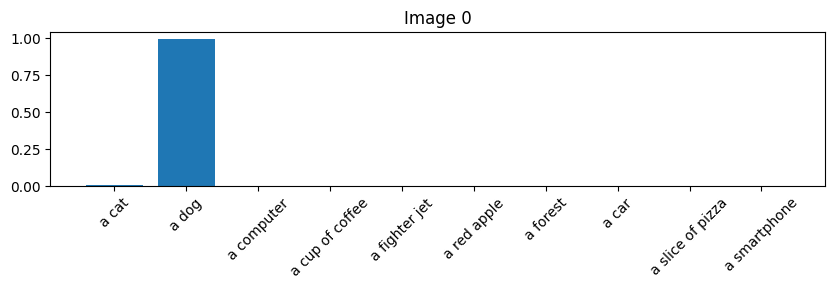

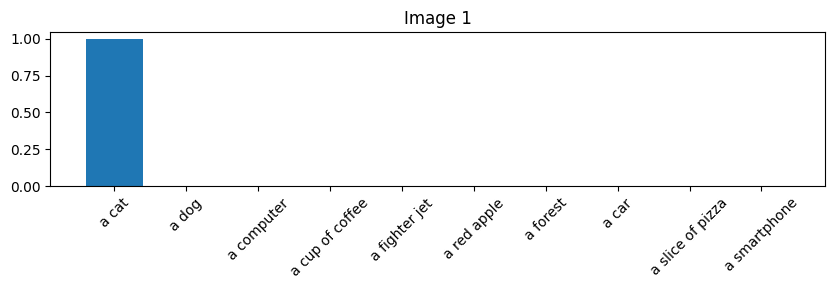

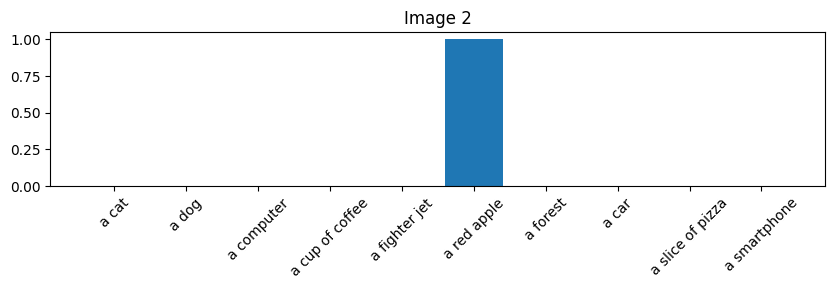

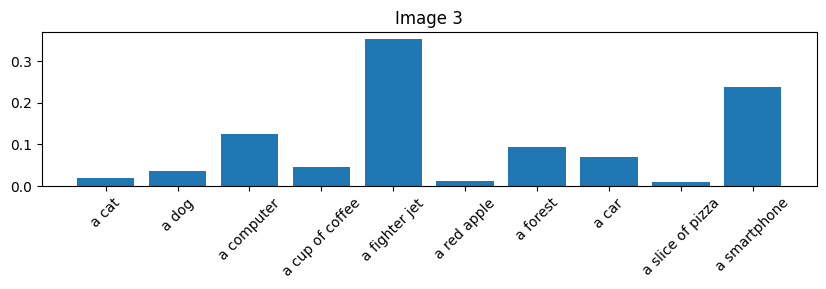

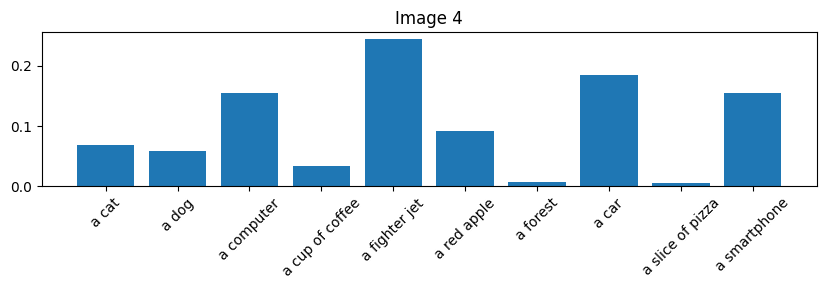

In [3]:
# б) Классификация с текстовыми описаниями
classes = ["a cat", "a dog", "a computer", "a cup of coffee", "a fighter jet", "a red apple", "a forest", "a car", "a slice of pizza", "a smartphone"]
text_inputs = clip.tokenize(classes).to(device)

with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)
    logits_per_image, _ = model(image_input, text_inputs)
    probs = logits_per_image.softmax(dim=-1).cpu().numpy()

for i, filename in enumerate(filenames):
    plt.figure(figsize=(10, 2))
    plt.bar(classes, probs[i])
    plt.title(f"Image {i}")
    plt.xticks(rotation=45)
    plt.show()


In [4]:
# в) Prompt engineering -- сравнение шаблонов
templates = ["{}", "a photo of a {}", "a close-up photo of a {}, high quality"]
test_class = "cat"
test_img = images[0]

for temp in templates:
    txt = clip.tokenize([temp.format(c) for c in classes]).to(device)
    with torch.no_grad():
        logits, _ = model(test_img, txt)
        prob = logits.softmax(dim=-1).cpu().numpy()[0]
        print(f"Template: '{temp}' -> Max Prob: {prob.max():.4f} for class: {classes[prob.argmax()]}")

Template: '{}' -> Max Prob: 0.9897 for class: a dog
Template: 'a photo of a {}' -> Max Prob: 0.9956 for class: a dog
Template: 'a close-up photo of a {}, high quality' -> Max Prob: 0.9941 for class: a dog


Картинка успешно загружена


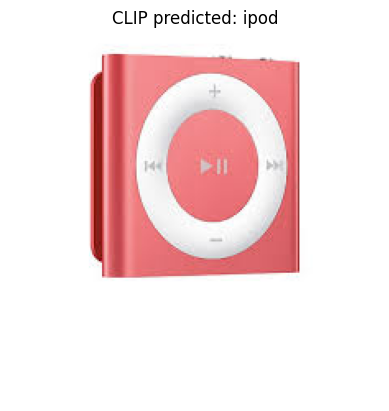

Результат: ipod с вероятностью 0.9980


In [5]:
# г) Попытка обмануть CLIP

trick_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRgZKa3waQFYTb3BHCLhk05-dMqDjxSkDTgFQ&s"
trick_name = "trick.jpg"

opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

try:
    urllib.request.urlretrieve(trick_url, trick_name)
    print("Картинка успешно загружена")

    trick_img = preprocess(Image.open(trick_name)).unsqueeze(0).to(device)
    trick_classes = ["apple", "ipod", "fruit", "electronics"]
    txt = clip.tokenize(trick_classes).to(device)

    with torch.no_grad():
        logits, _ = model(trick_img, txt)
        prob = logits.softmax(dim=-1).cpu().numpy()[0]

        plt.imshow(Image.open(trick_name))
        plt.title(f"CLIP predicted: {trick_classes[prob.argmax()]}")
        plt.axis('off')
        plt.show()

        print(f"Результат: {trick_classes[prob.argmax()]} с вероятностью {prob.max():.4f}")

except Exception as e:
    print(f"Ошибка при загрузке: {e}")

**Ваш вывод:** Какой шаблон промпта дал лучшие результаты? В каком случае CLIP ошибся и почему?

Более детальные шаблоны повышают уверенность модели, а ошибается CLIP из-за текста на картинках, так как он слишком сильно доверяет написанным словам



### Задание 2: Stable Diffusion -- генерация и исследование параметров

*(Слайды 11-15)*

Что надо сделать:

а) Загрузите SD 1.5 и сгенерируйте 3 картинки на тему Казахстана.
Используйте промпты на английском, описывающие казахские пейзажи, культуру или города.

б) Для одного промпта сравните результат с negative_prompt и без. Покажите оба варианта рядом.

в) Для одного промпта покажите сетку 2x2: `guidance_scale` = [3.0, 7.5, 12.0, 20.0].
Объясните, что происходит при слишком маленьком и слишком большом значении.

г) Используйте img2img: возьмите одну из сгенерированных картинок и переделайте её
в 3 разных стилях с разными значениями strength (0.3, 0.6, 0.9).

In [6]:
!pip install diffusers transformers accelerate -q
from diffusers import StableDiffusionPipeline, StableDiffusionImg2ImgPipeline

# Загрузка модели
pipe = StableDiffusionPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/50 [00:00<?, ?it/s]

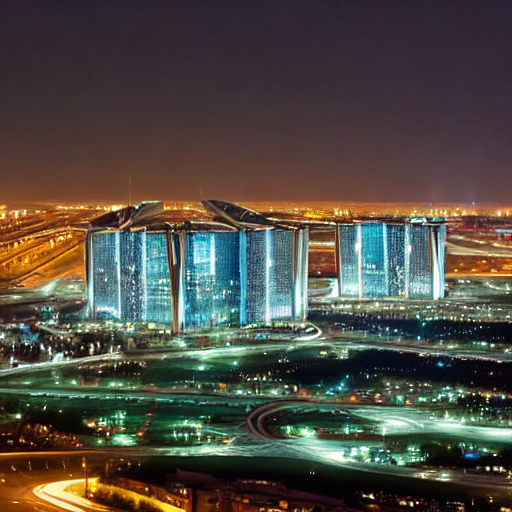

  0%|          | 0/50 [00:00<?, ?it/s]

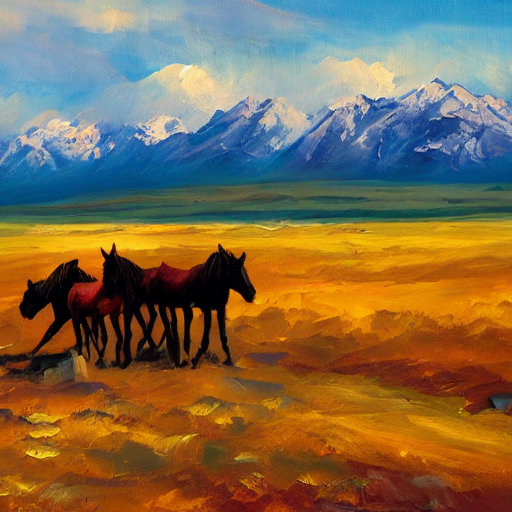

  0%|          | 0/50 [00:00<?, ?it/s]

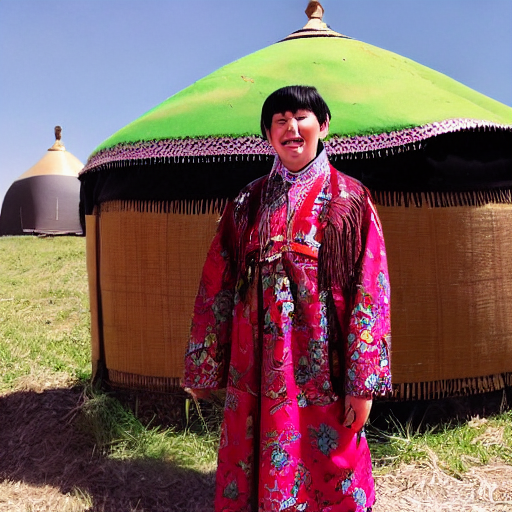

In [7]:
# а) 3 картинки на тему Казахстана
prompts = ["Astana city skyline at night, futuristic architecture, high quality",
           "Kazakh steppe with wild horses and mountains in background, oil painting style",
           "A person in traditional Kazakh clothes, yurt in background, realistic"]

images_kz = []
for p in prompts:
    img = pipe(p).images[0]
    images_kz.append(img)
    display(img)

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

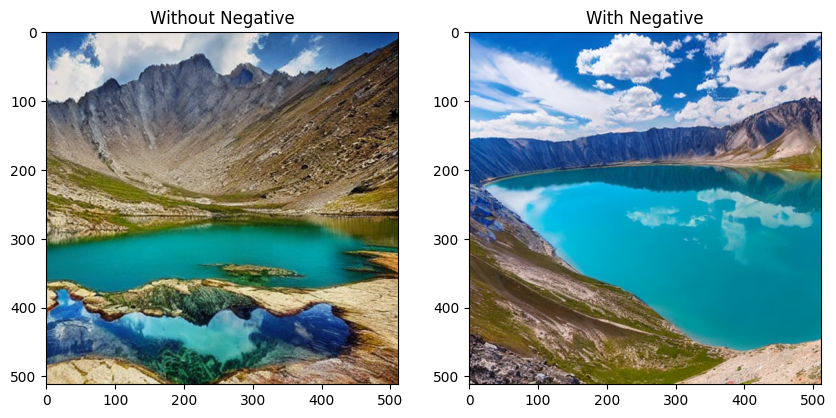

In [8]:
# б) Сравнение с negative_prompt и без
prompt = "A beautiful mountain lake in Kazakhstan, crystal clear water"
neg_prompt = "low quality, blurry, distorted, trees, people"

img_no_neg = pipe(prompt).images[0]
img_with_neg = pipe(prompt, negative_prompt=neg_prompt).images[0]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_no_neg); ax[0].set_title("Without Negative")
ax[1].imshow(img_with_neg); ax[1].set_title("With Negative")
plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

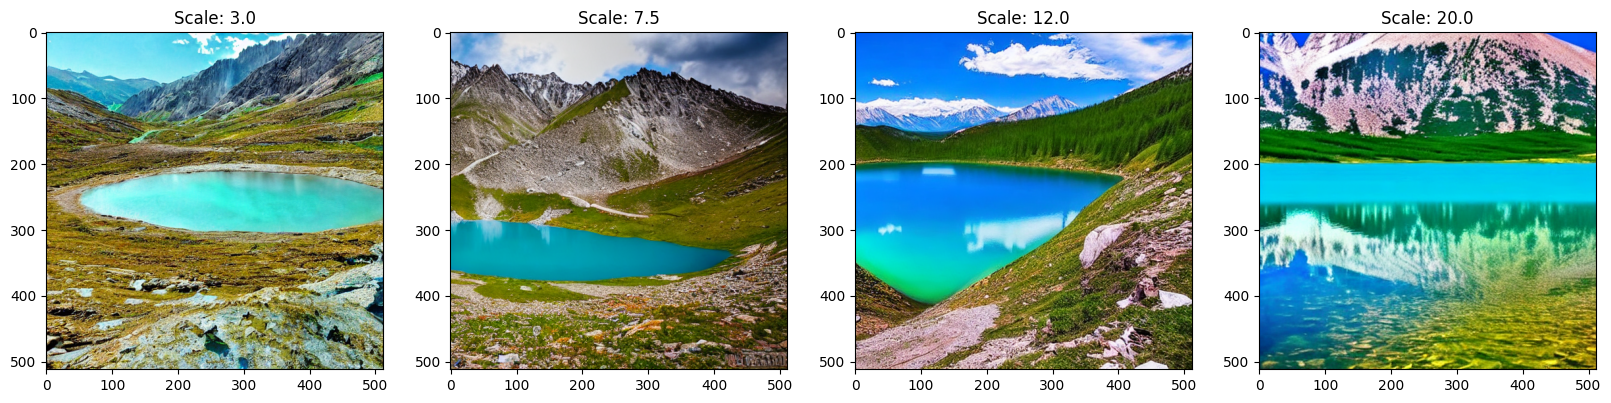

In [9]:
# в) Сетка guidance_scale
scales = [3.0, 7.5, 12.0, 20.0]
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
for i, s in enumerate(scales):
    img = pipe(prompt, guidance_scale=s).images[0]
    ax[i].imshow(img)
    ax[i].set_title(f"Scale: {s}")
plt.show()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  0%|          | 0/15 [00:00<?, ?it/s]

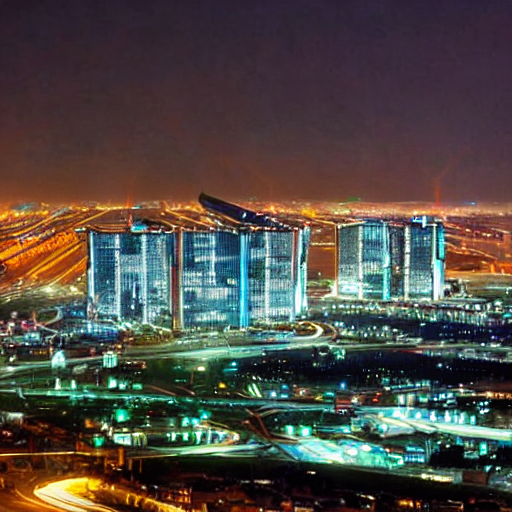

  0%|          | 0/30 [00:00<?, ?it/s]

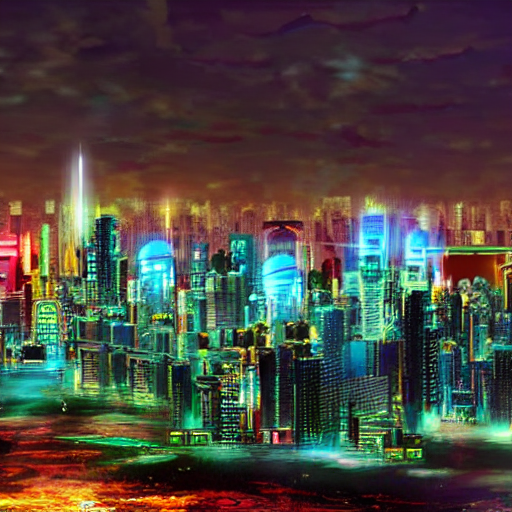

  0%|          | 0/45 [00:00<?, ?it/s]

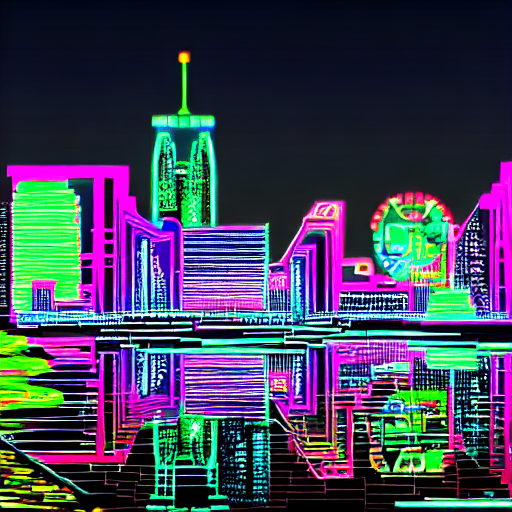

In [10]:
# г) img2img с разными стилями и strength
pipe_i2i = StableDiffusionImg2ImgPipeline.from_pretrained("runwayml/stable-diffusion-v1-5", torch_dtype=torch.float16).to(device)
init_img = images_kz[0].resize((512, 512))
strengths = [0.3, 0.6, 0.9]

for s in strengths:
    res = pipe_i2i(prompt="Cyberpunk neon style city", image=init_img, strength=s).images[0]
    display(res)

**Ваш вывод:** Как guidance_scale влияет на качество? Что происходит при strength=0.9 в img2img?

Низкий guidance_scale делает картинку размытой, а слишком высокий наоборот перенасыщенной. При strength = 0.9 исходное изображение почти полностью заменяется новым


### Задание 3: SAM -- сегментация своих картинок

*(Слайды 16-20)*

Что надо сделать:

а) Загрузите SAM ViT-B и скачайте картинку с 3+ разными объектами
(фото улицы, комнаты, или природы с животными).

б) Сегментируйте один объект по точке. Покажите все 3 маски, которые возвращает SAM.
Объясните, чем они отличаются (подсказка: разный масштаб сегментации).

в) Сегментируйте другой объект по bounding box. Нарисуйте бокс на исходной картинке
и покажите результат сегментации рядом.

г) Запустите автоматическую сегментацию (SamAutomaticMaskGenerator).
Визуализируйте все найденные маски разными цветами. Сколько объектов нашёл SAM?

д) Попробуйте комбинацию: точка на объекте (label=1) + точка на фоне (label=0).
Покажите, как точка на фоне помогает уточнить сегментацию.

In [11]:
# Освобождаем VRAM от SD если он ещё загружен
import gc
gc.collect()
torch.cuda.empty_cache()

!pip install segment-anything -q
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

from segment_anything import sam_model_registry, SamPredictor, SamAutomaticMaskGenerator
import cv2

# Загрузка модели
import numpy as np

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth").to(device)
predictor = SamPredictor(sam)

urllib.request.urlretrieve("https://raw.githubusercontent.com/facebookresearch/segment-anything/main/notebooks/images/truck.jpg", "sam_test.jpg")
image = cv2.imread("sam_test.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
predictor.set_image(image)

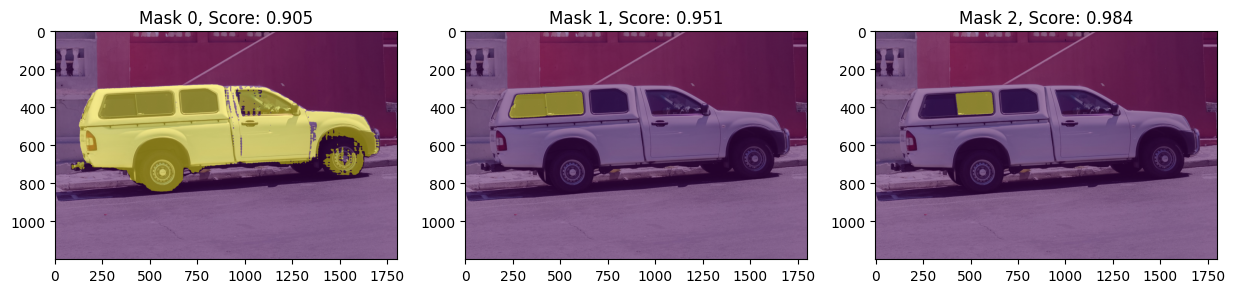

In [12]:
# б) Сегментация по точке
input_point = np.array([[500, 375]])
input_label = np.array([1])

masks, scores, logits = predictor.predict(point_coords=input_point, point_labels=input_label, multimask_output=True)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for i, (mask, score) in enumerate(zip(masks, scores)):
    ax[i].imshow(image)
    ax[i].imshow(mask, alpha=0.5)
    ax[i].set_title(f"Mask {i}, Score: {score:.3f}")
plt.show()

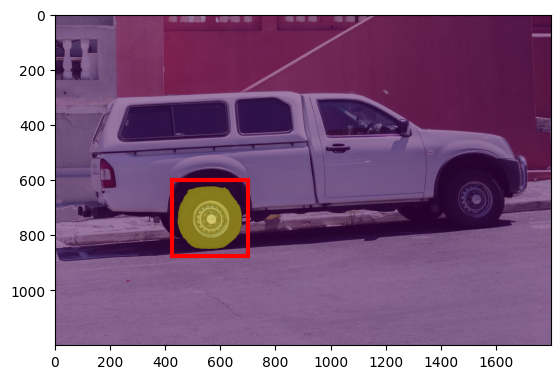

In [13]:
# в) Сегментация по bounding box
input_box = np.array([425, 600, 700, 875]) # [x1, y1, x2, y2]
masks_box, _, _ = predictor.predict(box=input_box, multimask_output=False)

plt.imshow(image)
plt.imshow(masks_box[0], alpha=0.5)
plt.gca().add_patch(plt.Rectangle((425, 600), 275, 275, fill=False, color='red', linewidth=3))
plt.show()

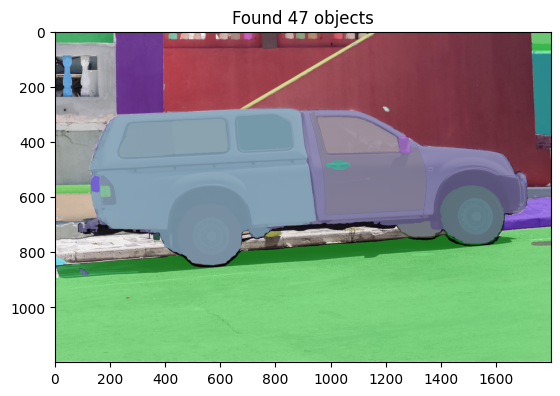

In [14]:
# г) Автоматическая сегментация
mask_generator = SamAutomaticMaskGenerator(sam)
auto_masks = mask_generator.generate(image)

plt.imshow(image)
ax = plt.gca()
for m in auto_masks:
    img = np.ones((m['segmentation'].shape[0], m['segmentation'].shape[1], 3))
    color = np.random.random(3)
    for i in range(3): img[:,:,i] = color[i]
    ax.imshow(np.dstack((img, m['segmentation']*0.5)))
plt.title(f"Found {len(auto_masks)} objects")
plt.show()

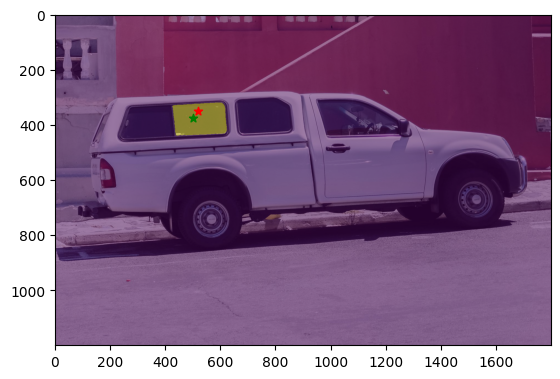

In [15]:
# д) Комбинация: точка на объекте + точка на фоне
# Подсказка: point_labels = np.array([1, 0]) -- первая точка на объекте, вторая на фоне
input_points = np.array([[500, 375], [520, 350]])
input_labels = np.array([1, 0])

masks_comb, _, _ = predictor.predict(point_coords=input_points, point_labels=input_labels, multimask_output=False)

plt.imshow(image)
plt.imshow(masks_comb[0], alpha=0.5)
plt.scatter(input_points[0,0], input_points[0,1], color='green', marker='*')
plt.scatter(input_points[1,0], input_points[1,1], color='red', marker='*')
plt.show()

**Ваш вывод:** Как три маски SAM отличаются друг от друга? Помогла ли точка на фоне уточнить сегментацию?

Три маски представляют разные уровни иерархии, а точка на фоне позволяет отсечь лишние области, которые модель ошибочно включила в маску



---

### Бонус: CLIP + SAM -- поиск и сегментация текстом

Это продвинутое задание. Идея: используем CLIP для поиска объекта по текстовому описанию,
а SAM для его сегментации.

Что надо сделать:

1) Загрузите картинку с несколькими разными объектами.

2) Запустите SAM автоматическую сегментацию, чтобы получить все маски.

3) Для каждой маски вырежьте соответствующий регион из картинки и прогоните через CLIP.

4) Задайте текстовый запрос (например, "a red car") и найдите маску с наибольшим cosine similarity к запросу.

5) Визуализируйте: исходная картинка -> найденная маска -> выделенный объект.

Подсказка: для вырезания региона используйте маску как фильтр:
```python
cropped = image.copy()
cropped[~mask] = 0  # зануляем пиксели вне маски
```

In [ ]:
# Бонус: CLIP + SAM
# Ваш код здесь


**Ваш вывод:** Насколько хорошо работает комбинация CLIP + SAM? Какие ограничения вы заметили?

